 Heart Disease Prediction — Supervised Classification

## 📌 Problem Statement
Predict whether a patient has **heart disease (1) or not (0)** based on 13 clinical features.

**Dataset:** Heart Disease Dataset (UCI / Kaggle)  
**Type:** Binary Classification (Supervised Learning)  
**Target Variable:** `target` — 1 = Heart Disease Present, 0 = No Heart Disease

---

## 📋 Table of Contents
1. Install & Import Libraries
2. Load Dataset
3. Data Understanding (EDA)
4. Data Cleaning
5. Data Visualization
6. Preprocessing (Feature Engineering, Scaling)
7. **Algorithm 1 — Random Forest Classifier** *(Best Pick)*
8. **Algorithm 2 — Logistic Regression**
9. **Algorithm 3 — Support Vector Machine (SVM)**
10. Model Comparison & Best Algorithm
11. Conclusion & Learnings

---
## Step 1 — Install & Import Libraries

In [62]:
# Install required libraries (if not already installed)
!pip install -q pandas numpy matplotlib seaborn scikit-learn

# ── Core Libraries ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-Learn: Preprocessing ──
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler

# ── Scikit-Learn: Algorithms ──
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# ── Scikit-Learn: Evaluation ──
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

print('✅ All libraries imported successfully!')

# Plot styling
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

✅ All libraries imported successfully!


---
## Step 2 — Load Dataset

> 📥 **Download from Kaggle:**  
> https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset  
> Upload `heart.csv` to Colab using the Files panel OR use the code below.

In [63]:
# ── Option A: Upload manually in Colab ──
# from google.colab import files
# uploaded = files.upload()   # click 'Choose Files' and select heart.csv

# ── Option B: Load directly from Kaggle URL ──
# !pip install -q kaggle
# Upload your kaggle.json API key, then:
# !kaggle datasets download -d johnsmith88/heart-disease-dataset --unzip

# ── Option C: Read from local path (adjust path as needed) ──
df = pd.read_csv('heart.csv')

print(f'✅ Dataset loaded successfully!')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')

✅ Dataset loaded successfully!
Shape: 1025 rows × 14 columns


---
## Step 3 — Data Understanding (EDA)

In [64]:
# ── First 5 rows ──
print('=== First 5 Rows ===')
df.head()

=== First 5 Rows ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [65]:
# ── Last 5 rows ──
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [66]:
# ── Dataset info: dtypes, non-null counts ──
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [67]:
# ── Statistical Summary ──
print('=== Statistical Summary ===')
df.describe().round(2)

=== Statistical Summary ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00
mean,54.43,0.70,0.94,131.61,246.00,0.15,0.53,149.11,0.34,1.07,1.39,0.75,2.32,0.51
std,9.07,0.46,1.03,17.52,51.59,0.36,0.53,23.01,0.47,1.18,0.62,1.03,0.62,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,0.00,120.00,211.00,0.00,0.00,132.00,0.00,0.00,1.00,0.00,2.00,0.00
50%,56.00,1.00,1.00,130.00,240.00,0.00,1.00,152.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,275.00,0.00,1.00,166.00,1.00,1.80,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


In [68]:
# ── Feature Descriptions ──
feature_desc = {
    'age'     : 'Age of the patient (years)',
    'sex'     : 'Sex — 1=Male, 0=Female',
    'cp'      : 'Chest pain type — 0:Typical Angina, 1:Atypical Angina, 2:Non-Anginal, 3:Asymptomatic',
    'trestbps': 'Resting Blood Pressure (mm Hg)',
    'chol'    : 'Serum Cholesterol (mg/dl)',
    'fbs'     : 'Fasting Blood Sugar > 120 mg/dl (1=True, 0=False)',
    'restecg' : 'Resting ECG Results (0/1/2)',
    'thalach' : 'Maximum Heart Rate Achieved',
    'exang'   : 'Exercise-Induced Angina (1=Yes, 0=No)',
    'oldpeak' : 'ST Depression Induced by Exercise',
    'slope'   : 'Slope of Peak Exercise ST Segment (0/1/2)',
    'ca'      : 'Number of Major Vessels Colored by Fluoroscopy (0-3)',
    'thal'    : 'Thal — 0:Normal, 1:Fixed Defect, 2:Reversible Defect',
    'target'  : '🎯 TARGET — 1=Heart Disease, 0=No Heart Disease'
}

print('=== Feature Descriptions ===')
for col, desc in feature_desc.items():
    print(f'  {col:<12} → {desc}')

=== Feature Descriptions ===
  age          → Age of the patient (years)
  sex          → Sex — 1=Male, 0=Female
  cp           → Chest pain type — 0:Typical Angina, 1:Atypical Angina, 2:Non-Anginal, 3:Asymptomatic
  trestbps     → Resting Blood Pressure (mm Hg)
  chol         → Serum Cholesterol (mg/dl)
  fbs          → Fasting Blood Sugar > 120 mg/dl (1=True, 0=False)
  restecg      → Resting ECG Results (0/1/2)
  thalach      → Maximum Heart Rate Achieved
  exang        → Exercise-Induced Angina (1=Yes, 0=No)
  oldpeak      → ST Depression Induced by Exercise
  slope        → Slope of Peak Exercise ST Segment (0/1/2)
  ca           → Number of Major Vessels Colored by Fluoroscopy (0-3)
  thal         → Thal — 0:Normal, 1:Fixed Defect, 2:Reversible Defect
  target       → 🎯 TARGET — 1=Heart Disease, 0=No Heart Disease


In [69]:
# ── Target Distribution ──
print('=== Target Variable Distribution ===')
print(df['target'].value_counts())
print(f'\nClass Balance: {df["target"].value_counts(normalize=True).round(3).to_dict()}')

=== Target Variable Distribution ===
target
1    526
0    499
Name: count, dtype: int64

Class Balance: {1: 0.513, 0: 0.487}


---
## Step 4 — Data Cleaning

In [70]:
# ── Check for Missing Values ──
print('=== Missing Values per Column ===')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing values: {missing.sum()}')

=== Missing Values per Column ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing values: 0


In [71]:
# ── Check for Duplicate Rows ──
duplicates = df.duplicated().sum()
print(f'Duplicate rows found: {duplicates}')

if duplicates > 0:
    df = df.drop_duplicates()
    print(f'✅ Duplicates removed. New shape: {df.shape}')
else:
    print('✅ No duplicates found.')

Duplicate rows found: 723
✅ Duplicates removed. New shape: (302, 14)


In [72]:
# ── Check for Outliers using IQR Method ──
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

print('=== Outlier Detection (IQR Method) ===')
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f'  {col:<12} → Outliers: {outliers} (range: [{lower:.1f}, {upper:.1f}])')

=== Outlier Detection (IQR Method) ===
  age          → Outliers: 0 (range: [28.5, 80.5])
  trestbps     → Outliers: 9 (range: [90.0, 170.0])
  chol         → Outliers: 5 (range: [115.4, 370.4])
  thalach      → Outliers: 1 (range: [84.1, 215.1])
  oldpeak      → Outliers: 5 (range: [-2.4, 4.0])


In [73]:
# ── Handle chol=0 (physiologically impossible) ──
print(f'Rows where chol == 0: {(df["chol"] == 0).sum()}')
if (df['chol'] == 0).sum() > 0:
    # Replace 0 cholesterol with median (safer than dropping)
    median_chol = df[df['chol'] > 0]['chol'].median()
    df['chol'] = df['chol'].replace(0, median_chol)
    print(f'✅ Replaced 0 cholesterol with median: {median_chol}')

print(f'\n✅ Final cleaned dataset shape: {df.shape}')

Rows where chol == 0: 0

✅ Final cleaned dataset shape: (302, 14)


---
## Step 5 — Data Visualization

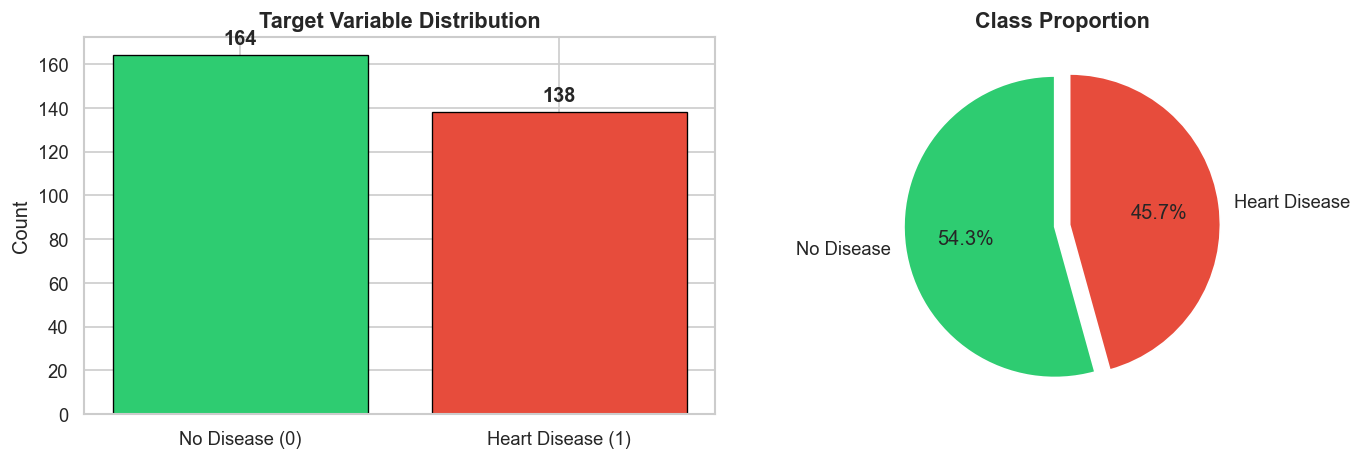

📊 Dataset is nearly balanced — no need for SMOTE/oversampling.


In [74]:
# ── 5.1 Target Distribution (Bar + Pie) ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar Chart
counts = df['target'].value_counts()
axes[0].bar(['No Disease (0)', 'Heart Disease (1)'], counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.8)
axes[0].set_title('Target Variable Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie Chart
axes[1].pie(counts.values, labels=['No Disease', 'Heart Disease'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
print('📊 Dataset is nearly balanced — no need for SMOTE/oversampling.')

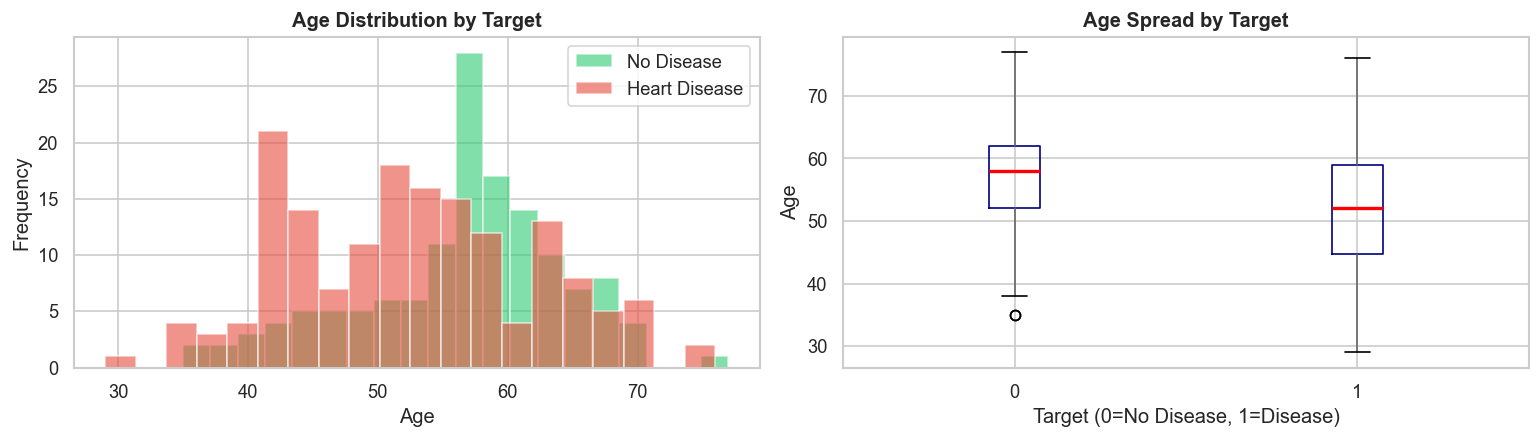

In [75]:
# ── 5.2 Age Distribution by Target ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
df[df['target']==0]['age'].plot(kind='hist', bins=20, alpha=0.6,
                                 color='#2ecc71', label='No Disease', ax=axes[0])
df[df['target']==1]['age'].plot(kind='hist', bins=20, alpha=0.6,
                                 color='#e74c3c', label='Heart Disease', ax=axes[0])
axes[0].set_title('Age Distribution by Target', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].legend()

# Box Plot
df.boxplot(column='age', by='target', ax=axes[1],
           boxprops=dict(color='navy'), medianprops=dict(color='red', lw=2))
axes[1].set_title('Age Spread by Target', fontweight='bold')
axes[1].set_xlabel('Target (0=No Disease, 1=Disease)')
axes[1].set_ylabel('Age')
plt.suptitle('')

plt.tight_layout()
plt.show()

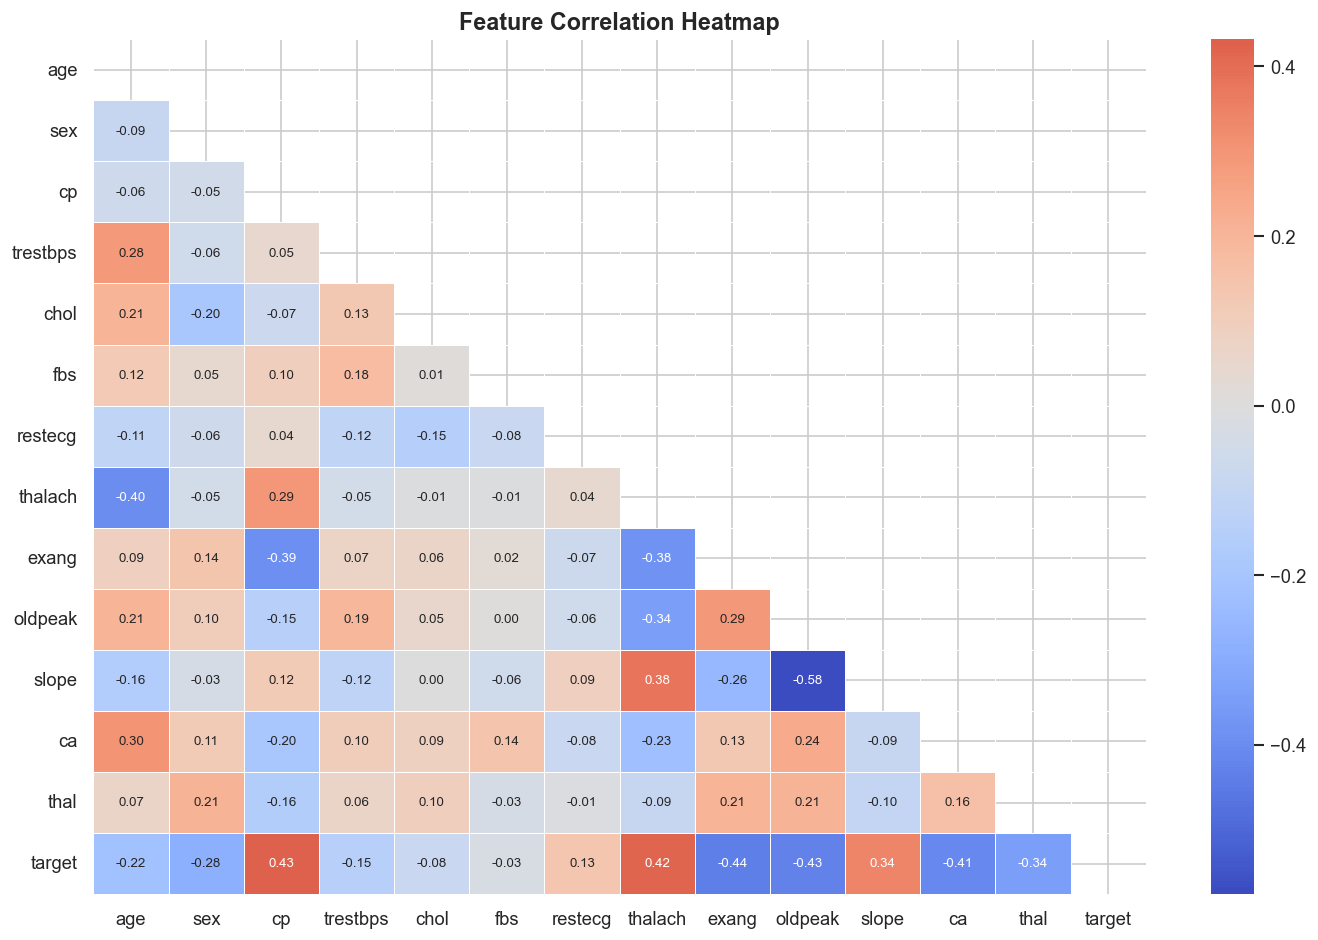


=== Top Correlations with Target ===
exang       0.436
cp          0.432
oldpeak     0.429
thalach     0.420
ca          0.409
slope       0.344
thal        0.343
sex         0.284
age         0.221
trestbps    0.146
restecg     0.135
chol        0.081
fbs         0.027
Name: target, dtype: float64


In [76]:
# ── 5.3 Correlation Heatmap ──
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', mask=mask,
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with target
print('\n=== Top Correlations with Target ===')
target_corr = corr_matrix['target'].drop('target').abs().sort_values(ascending=False)
print(target_corr.round(3))

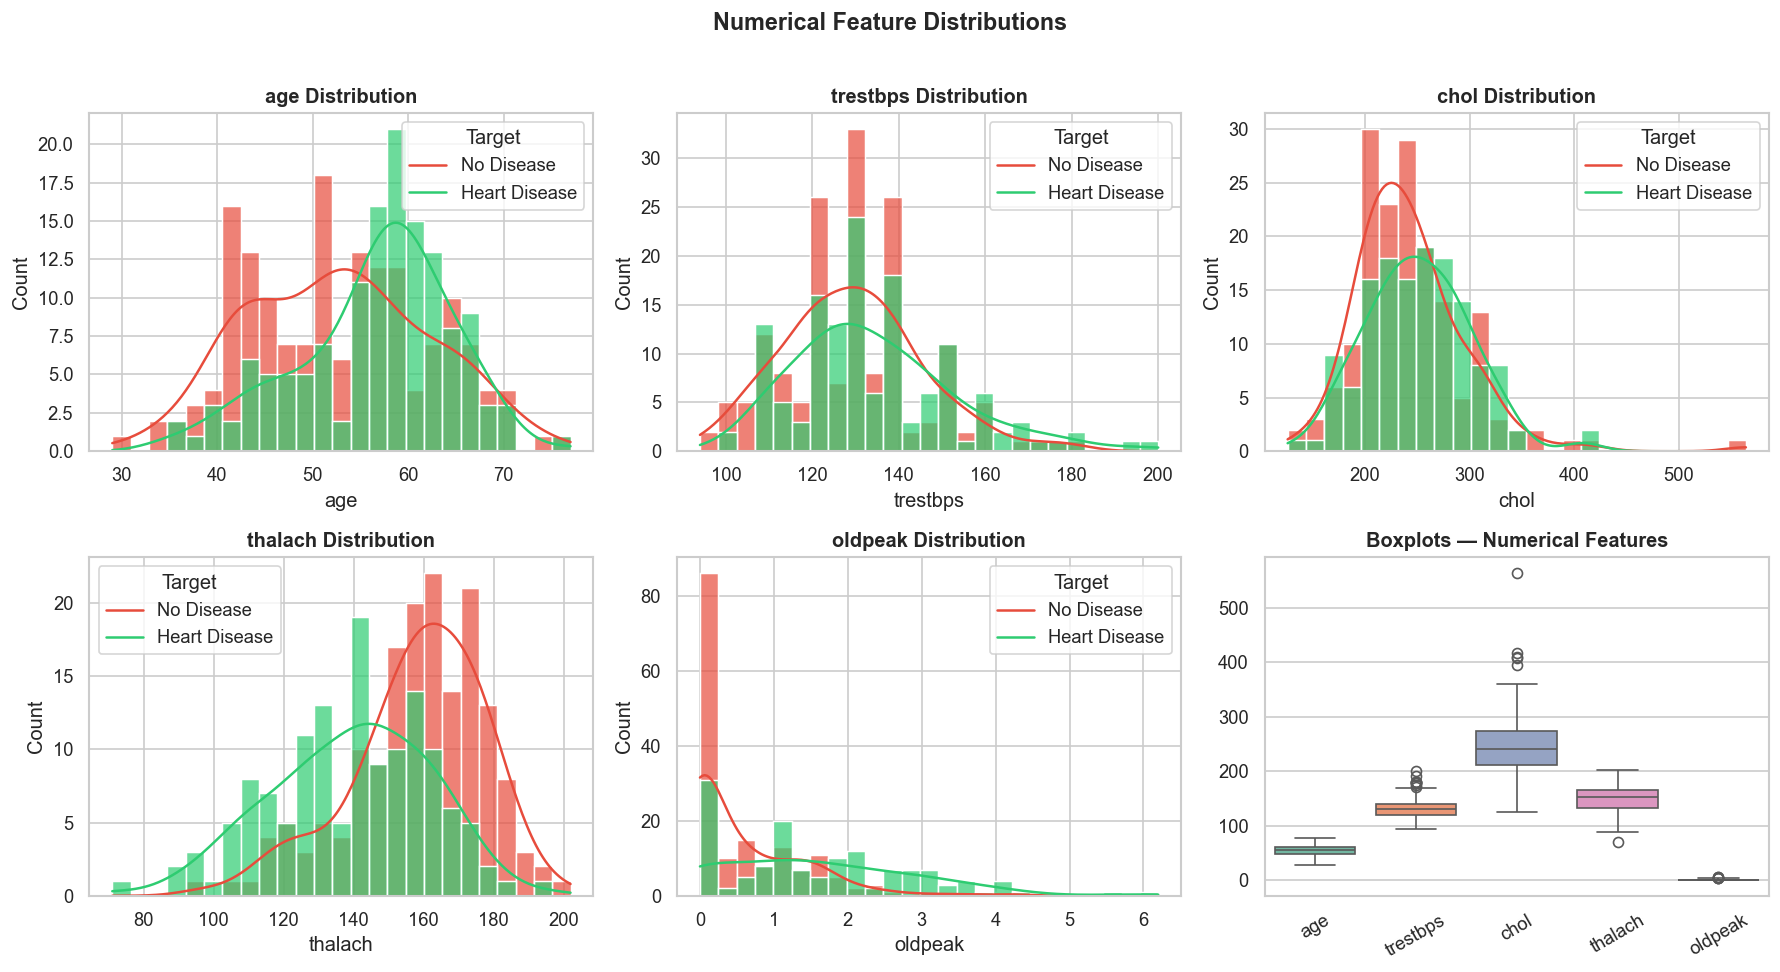

In [77]:
# ── 5.4 Distribution of Numerical Features ──
num_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(data=df, x=col, hue='target', bins=25,
                 ax=axes[i], palette={0: '#2ecc71', 1: '#e74c3c'},
                 alpha=0.7, kde=True)
    axes[i].set_title(f'{col} Distribution', fontweight='bold')
    axes[i].legend(title='Target', labels=['No Disease', 'Heart Disease'])

# Boxplot grid for outliers
sns.boxplot(data=df[num_features], ax=axes[5], palette='Set2')
axes[5].set_title('Boxplots — Numerical Features', fontweight='bold')
axes[5].tick_params(axis='x', rotation=30)

plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

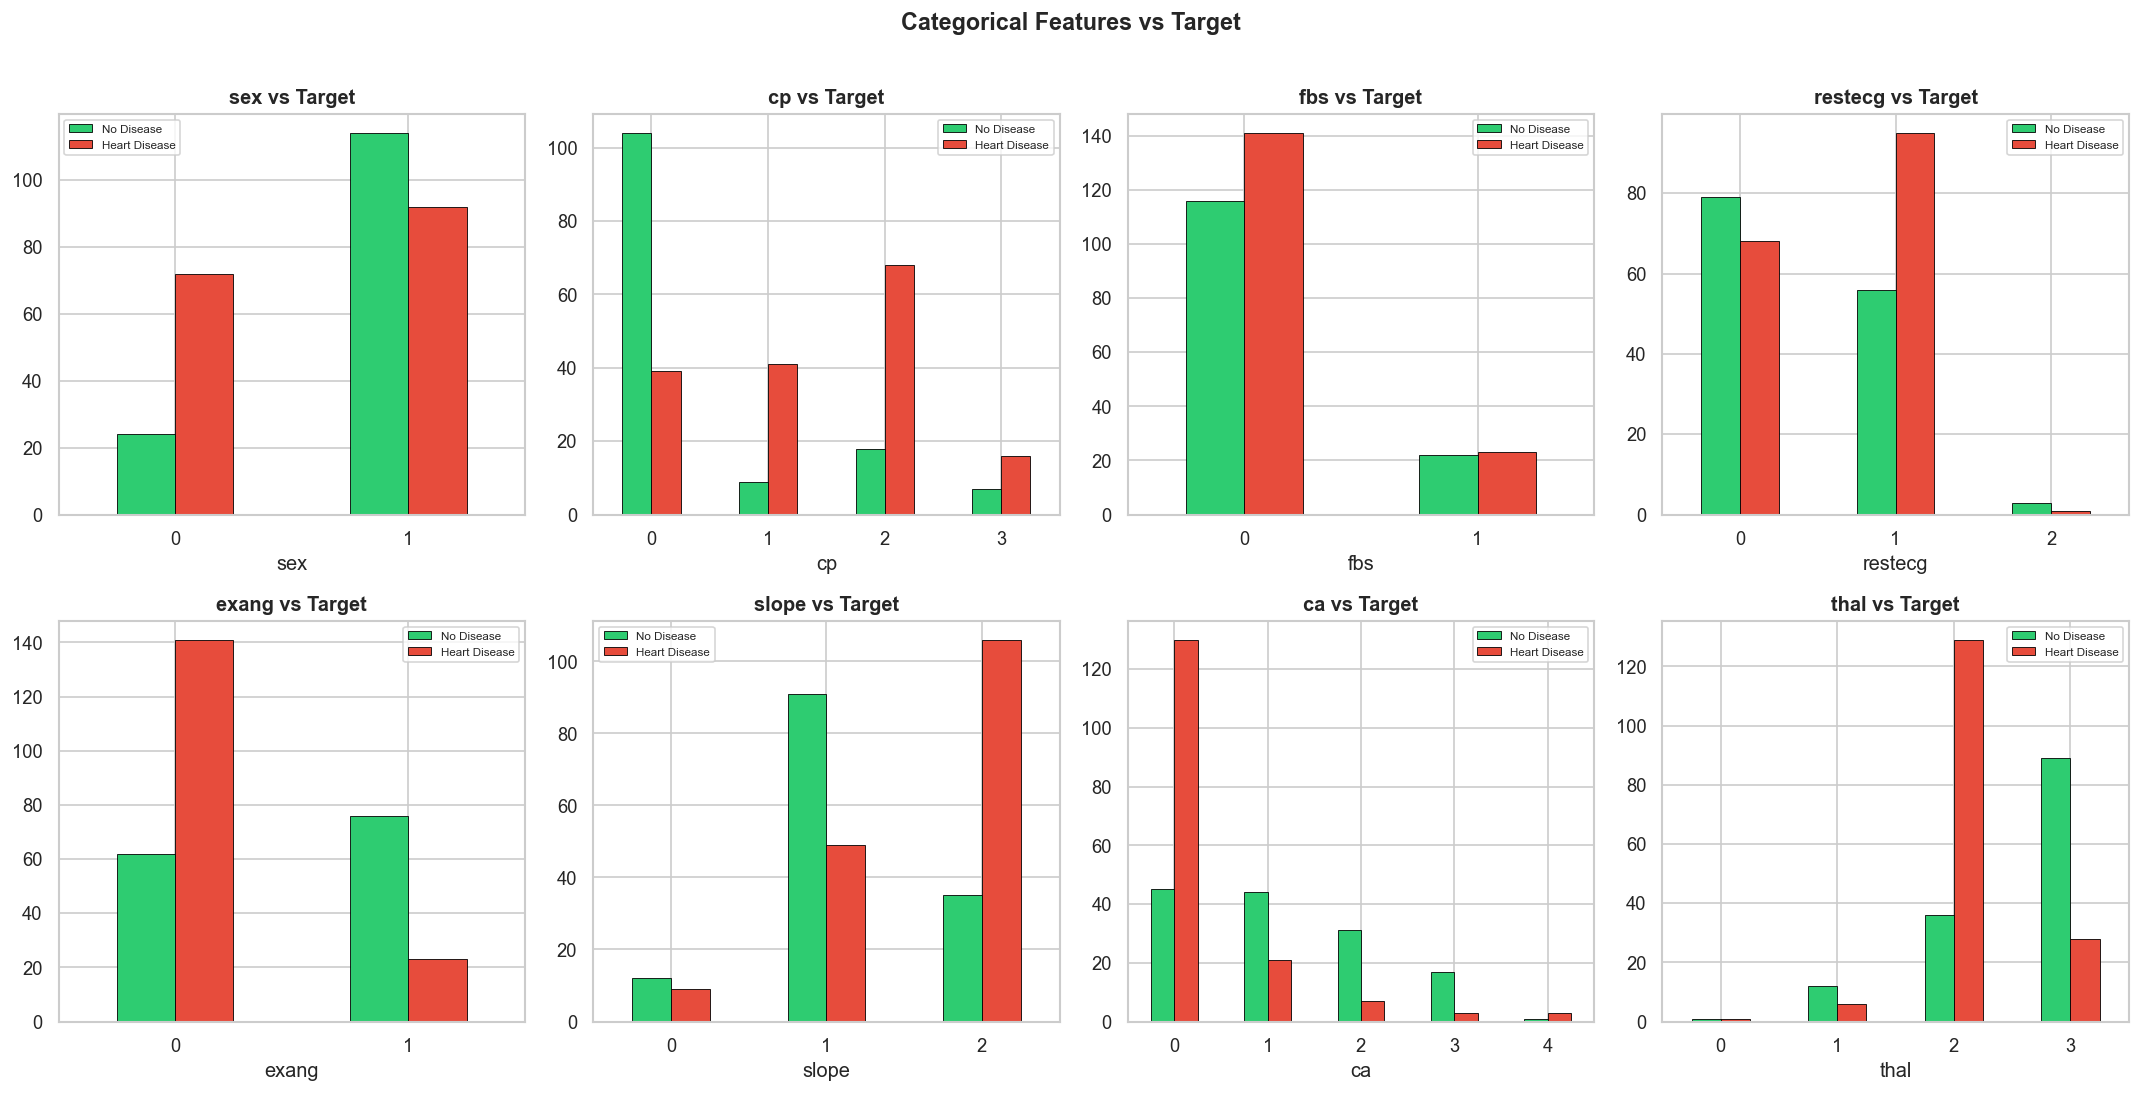

In [78]:
# ── 5.5 Categorical Features vs Target ──
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    ct = pd.crosstab(df[col], df['target'])
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'],
            edgecolor='black', linewidth=0.5, rot=0)
    axes[i].set_title(f'{col} vs Target', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].legend(['No Disease', 'Heart Disease'], fontsize=7)

plt.suptitle('Categorical Features vs Target', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

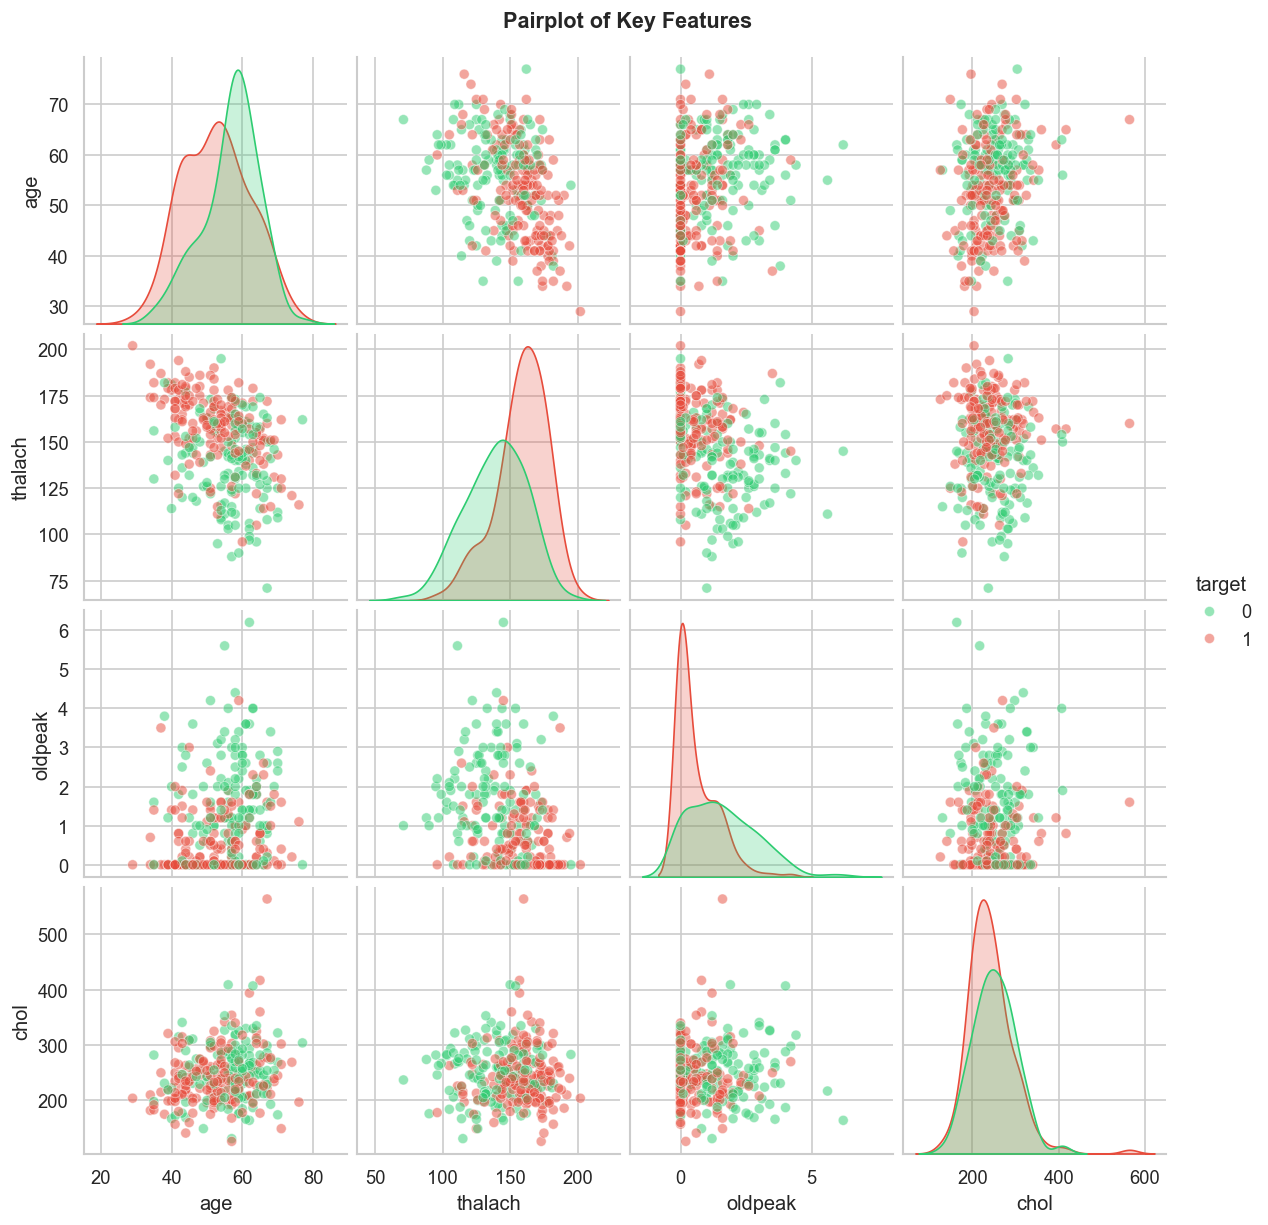

In [79]:
# ── 5.6 Pairplot (Key Features) ──
key_features = ['age', 'thalach', 'oldpeak', 'chol', 'target']
sns.pairplot(df[key_features], hue='target',
             palette={0: '#2ecc71', 1: '#e74c3c'},
             plot_kws={'alpha': 0.5}, diag_kind='kde')
plt.suptitle('Pairplot of Key Features', y=1.02, fontsize=13, fontweight='bold')
plt.show()

---
## Step 6 — Preprocessing

In [80]:
# ── 6.1 Separate Features and Target ──
X = df.drop('target', axis=1)
y = df['target']

print(f'Features (X): {X.shape}')
print(f'Target  (y): {y.shape}')
print(f'Feature names: {list(X.columns)}')

Features (X): (302, 13)
Target  (y): (302,)
Feature names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [81]:
# ── 6.2 Train-Test Split (80/20 Stratified) ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set  : {X_train.shape[0]} samples')
print(f'Test set      : {X_test.shape[0]} samples')
print(f'Train class dist: {dict(y_train.value_counts())}')
print(f'Test  class dist: {dict(y_test.value_counts())}')

Training set  : 241 samples
Test set      : 61 samples
Train class dist: {1: np.int64(131), 0: np.int64(110)}
Test  class dist: {1: np.int64(33), 0: np.int64(28)}


In [82]:
# ── 6.3 Feature Scaling (StandardScaler) ──
# NOTE: Scaling is needed for SVM & Logistic Regression
# Random Forest is tree-based so it doesn't require scaling,
# but we scale all for fair comparison

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('✅ Feature scaling complete.')
print(f'Train mean (post-scale): {X_train_scaled.mean():.4f}  (should be ~0)')
print(f'Train std  (post-scale): {X_train_scaled.std():.4f}  (should be ~1)')

✅ Feature scaling complete.
Train mean (post-scale): -0.0000  (should be ~0)
Train std  (post-scale): 1.0000  (should be ~1)


---
## Step 7 — Algorithm 1: Random Forest Classifier 🌲 *(Best Pick)*

### 🏆 Why Random Forest?
1. **Ensemble power** — Combines 100s of decision trees → reduces variance and overfitting
2. **Handles mixed feature types** — Works well with both continuous (age, chol) and categorical (cp, thal) features
3. **No scaling needed** — Tree-based; not sensitive to feature magnitude
4. **Feature importance** — Built-in ranking of which features matter most
5. **Robust to outliers** — Median-based splits are not affected by extreme values
6. **Handles class imbalance** — `class_weight='balanced'` option available
7. **Low hyperparameter sensitivity** — Performs well even with default settings
8. **Non-linear relationships** — Can capture complex interactions (e.g., cp × thalach)

In [83]:
# ── 7.1 Train Random Forest ──
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)
print('✅ Random Forest trained!')

✅ Random Forest trained!


In [84]:
# ── 7.2 Predictions ──
rf_pred  = rf_model.predict(X_test_scaled)
rf_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# ── 7.3 Metrics ──
rf_acc  = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred)
rf_rec  = recall_score(y_test, rf_pred)
rf_f1   = f1_score(y_test, rf_pred)
rf_auc  = roc_auc_score(y_test, rf_proba)

print('=== Random Forest Performance ===')
print(f'  Accuracy  : {rf_acc:.4f}')
print(f'  Precision : {rf_prec:.4f}')
print(f'  Recall    : {rf_rec:.4f}')
print(f'  F1-Score  : {rf_f1:.4f}')
print(f'  ROC-AUC   : {rf_auc:.4f}')

print('\n=== Classification Report ===')
print(classification_report(y_test, rf_pred, target_names=['No Disease','Heart Disease']))

=== Random Forest Performance ===
  Accuracy  : 0.7541
  Precision : 0.7647
  Recall    : 0.7879
  F1-Score  : 0.7761
  ROC-AUC   : 0.8680

=== Classification Report ===
               precision    recall  f1-score   support

   No Disease       0.74      0.71      0.73        28
Heart Disease       0.76      0.79      0.78        33

     accuracy                           0.75        61
    macro avg       0.75      0.75      0.75        61
 weighted avg       0.75      0.75      0.75        61



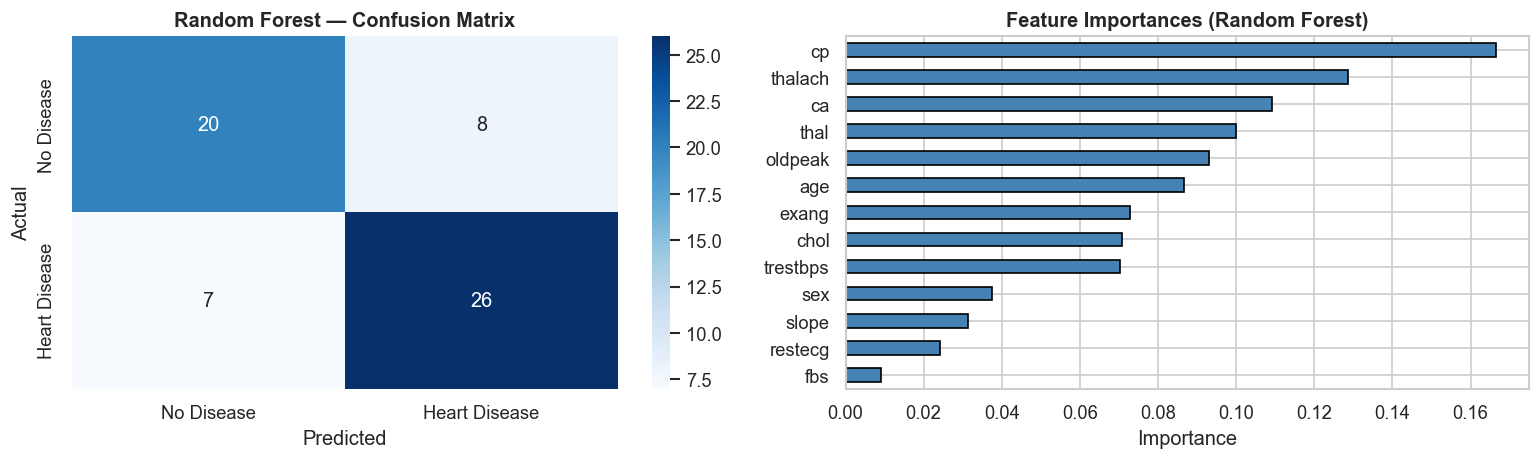

In [85]:
# ── 7.4 Confusion Matrix ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confusion matrix
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Disease','Heart Disease'],
            yticklabels=['No Disease','Heart Disease'])
axes[0].set_title('Random Forest — Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Feature Importance
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)
feat_imp.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Feature Importances (Random Forest)', fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

In [86]:
# ── 7.5 Cross-Validation (5-Fold) ──
rf_cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f'Random Forest CV Accuracy: {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}')
print(f'Fold Scores: {rf_cv_scores.round(4)}')

Random Forest CV Accuracy: 0.8173 ± 0.0164
Fold Scores: [0.8367 0.7917 0.8125 0.8125 0.8333]


---
## Step 8 — Algorithm 2: Logistic Regression 📈

In [87]:
# ── 8.1 Train Logistic Regression ──
lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)
print('✅ Logistic Regression trained!')

✅ Logistic Regression trained!


In [88]:
# ── 8.2 Predictions & Metrics ──
lr_pred  = lr_model.predict(X_test_scaled)
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

lr_acc  = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred)
lr_rec  = recall_score(y_test, lr_pred)
lr_f1   = f1_score(y_test, lr_pred)
lr_auc  = roc_auc_score(y_test, lr_proba)

print('=== Logistic Regression Performance ===')
print(f'  Accuracy  : {lr_acc:.4f}')
print(f'  Precision : {lr_prec:.4f}')
print(f'  Recall    : {lr_rec:.4f}')
print(f'  F1-Score  : {lr_f1:.4f}')
print(f'  ROC-AUC   : {lr_auc:.4f}')

print('\n=== Classification Report ===')
print(classification_report(y_test, lr_pred, target_names=['No Disease','Heart Disease']))

=== Logistic Regression Performance ===
  Accuracy  : 0.8033
  Precision : 0.8000
  Recall    : 0.8485
  F1-Score  : 0.8235
  ROC-AUC   : 0.8712

=== Classification Report ===
               precision    recall  f1-score   support

   No Disease       0.81      0.75      0.78        28
Heart Disease       0.80      0.85      0.82        33

     accuracy                           0.80        61
    macro avg       0.80      0.80      0.80        61
 weighted avg       0.80      0.80      0.80        61



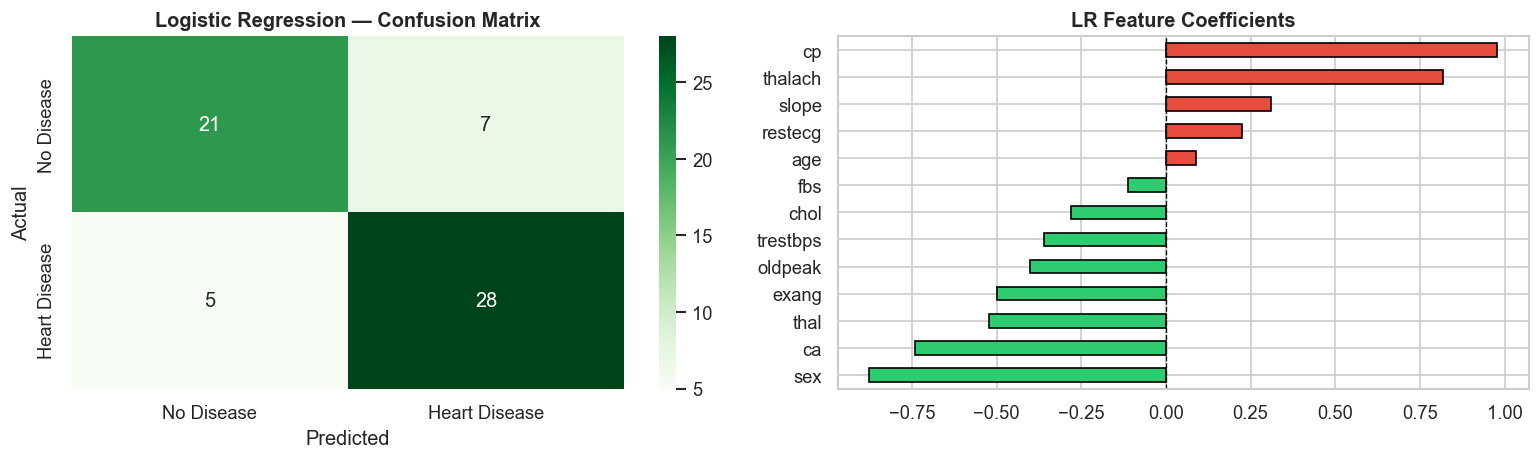

In [89]:
# ── 8.3 Confusion Matrix + Coefficients ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['No Disease','Heart Disease'],
            yticklabels=['No Disease','Heart Disease'])
axes[0].set_title('Logistic Regression — Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Feature coefficients
coef_df = pd.Series(lr_model.coef_[0], index=X.columns).sort_values()
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in coef_df]
coef_df.plot(kind='barh', ax=axes[1], color=colors, edgecolor='black')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('LR Feature Coefficients', fontweight='bold')

plt.tight_layout()
plt.show()

In [90]:
# ── 8.4 Cross-Validation ──
lr_cv_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f'Logistic Regression CV Accuracy: {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}')
print(f'Fold Scores: {lr_cv_scores.round(4)}')

Logistic Regression CV Accuracy: 0.8216 ± 0.0210
Fold Scores: [0.8163 0.7917 0.8333 0.8125 0.8542]


---
## Step 9 — Algorithm 3: Support Vector Machine (SVM) 🤖

In [91]:
# ── 9.1 Train SVM ──
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,     # needed for predict_proba & ROC-AUC
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)
print('✅ SVM trained!')

✅ SVM trained!


In [92]:
# ── 9.2 Predictions & Metrics ──
svm_pred  = svm_model.predict(X_test_scaled)
svm_proba = svm_model.predict_proba(X_test_scaled)[:, 1]

svm_acc  = accuracy_score(y_test, svm_pred)
svm_prec = precision_score(y_test, svm_pred)
svm_rec  = recall_score(y_test, svm_pred)
svm_f1   = f1_score(y_test, svm_pred)
svm_auc  = roc_auc_score(y_test, svm_proba)

print('=== SVM Performance ===')
print(f'  Accuracy  : {svm_acc:.4f}')
print(f'  Precision : {svm_prec:.4f}')
print(f'  Recall    : {svm_rec:.4f}')
print(f'  F1-Score  : {svm_f1:.4f}')
print(f'  ROC-AUC   : {svm_auc:.4f}')

print('\n=== Classification Report ===')
print(classification_report(y_test, svm_pred, target_names=['No Disease','Heart Disease']))

=== SVM Performance ===
  Accuracy  : 0.7705
  Precision : 0.7714
  Recall    : 0.8182
  F1-Score  : 0.7941
  ROC-AUC   : 0.8420

=== Classification Report ===
               precision    recall  f1-score   support

   No Disease       0.77      0.71      0.74        28
Heart Disease       0.77      0.82      0.79        33

     accuracy                           0.77        61
    macro avg       0.77      0.77      0.77        61
 weighted avg       0.77      0.77      0.77        61



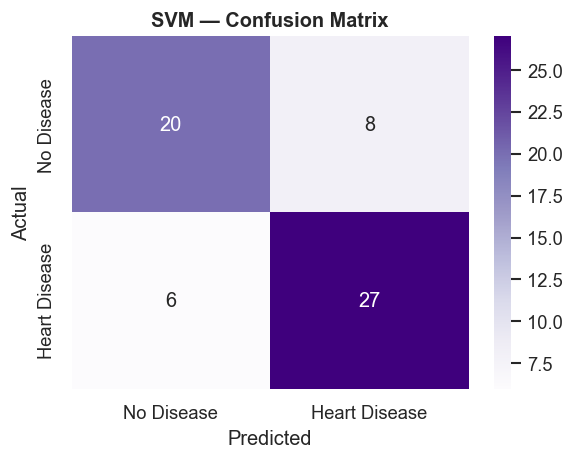

In [93]:
# ── 9.3 Confusion Matrix ──
fig, ax = plt.subplots(figsize=(5, 4))
cm_svm = confusion_matrix(y_test, svm_pred)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples', ax=ax,
            xticklabels=['No Disease','Heart Disease'],
            yticklabels=['No Disease','Heart Disease'])
ax.set_title('SVM — Confusion Matrix', fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

In [94]:
# ── 9.4 Cross-Validation ──
svm_cv_scores = cross_val_score(svm_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f'SVM CV Accuracy: {svm_cv_scores.mean():.4f} ± {svm_cv_scores.std():.4f}')
print(f'Fold Scores: {svm_cv_scores.round(4)}')

SVM CV Accuracy: 0.8132 ± 0.0327
Fold Scores: [0.8367 0.8333 0.8125 0.8333 0.75  ]


---
## Step 10 — Model Comparison & Best Algorithm

In [95]:
# ── 10.1 Comparison Table ──
results = pd.DataFrame({
    'Model'     : ['Random Forest 🌲', 'Logistic Regression 📈', 'SVM 🤖'],
    'Accuracy'  : [rf_acc,  lr_acc,  svm_acc],
    'Precision' : [rf_prec, lr_prec, svm_prec],
    'Recall'    : [rf_rec,  lr_rec,  svm_rec],
    'F1-Score'  : [rf_f1,   lr_f1,   svm_f1],
    'ROC-AUC'   : [rf_auc,  lr_auc,  svm_auc],
    'CV Accuracy Mean' : [rf_cv_scores.mean(), lr_cv_scores.mean(), svm_cv_scores.mean()],
    'CV Std'    : [rf_cv_scores.std(),  lr_cv_scores.std(),  svm_cv_scores.std()]
})

results = results.set_index('Model')
results = results.round(4)
print('=== Complete Model Comparison ===')
print(results.to_string())

=== Complete Model Comparison ===
                       Accuracy  Precision  Recall  F1-Score  ROC-AUC  CV Accuracy Mean  CV Std
Model                                                                                          
Random Forest 🌲          0.7541     0.7647  0.7879    0.7761   0.8680            0.8173  0.0164
Logistic Regression 📈    0.8033     0.8000  0.8485    0.8235   0.8712            0.8216  0.0210
SVM 🤖                    0.7705     0.7714  0.8182    0.7941   0.8420            0.8132  0.0327


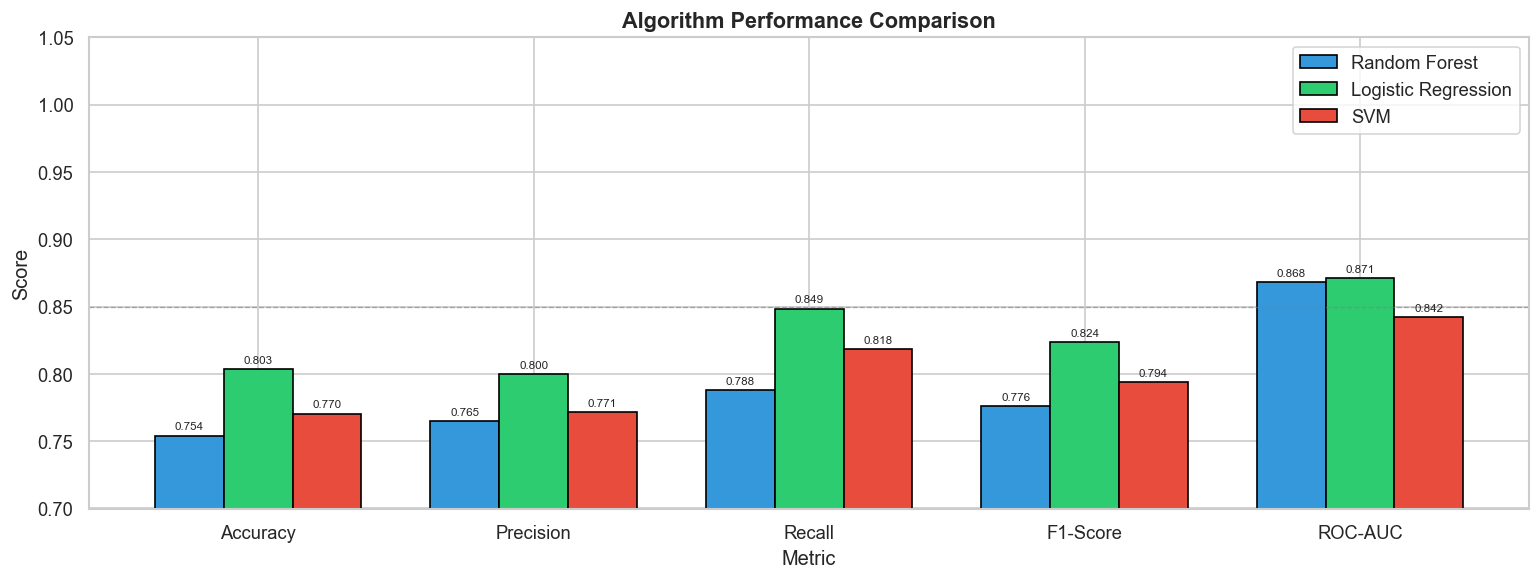

In [96]:
# ── 10.2 Bar Chart Comparison ──
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width, results.loc['Random Forest 🌲', metrics], width,
               label='Random Forest', color='#3498db', edgecolor='black')
bars2 = ax.bar(x,          results.loc['Logistic Regression 📈', metrics], width,
               label='Logistic Regression', color='#2ecc71', edgecolor='black')
bars3 = ax.bar(x + width, results.loc['SVM 🤖', metrics], width,
               label='SVM', color='#e74c3c', edgecolor='black')

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Algorithm Performance Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.7, 1.05)
ax.legend()
ax.axhline(y=0.85, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

# Value labels
for bar_group in [bars1, bars2, bars3]:
    for bar in bar_group:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

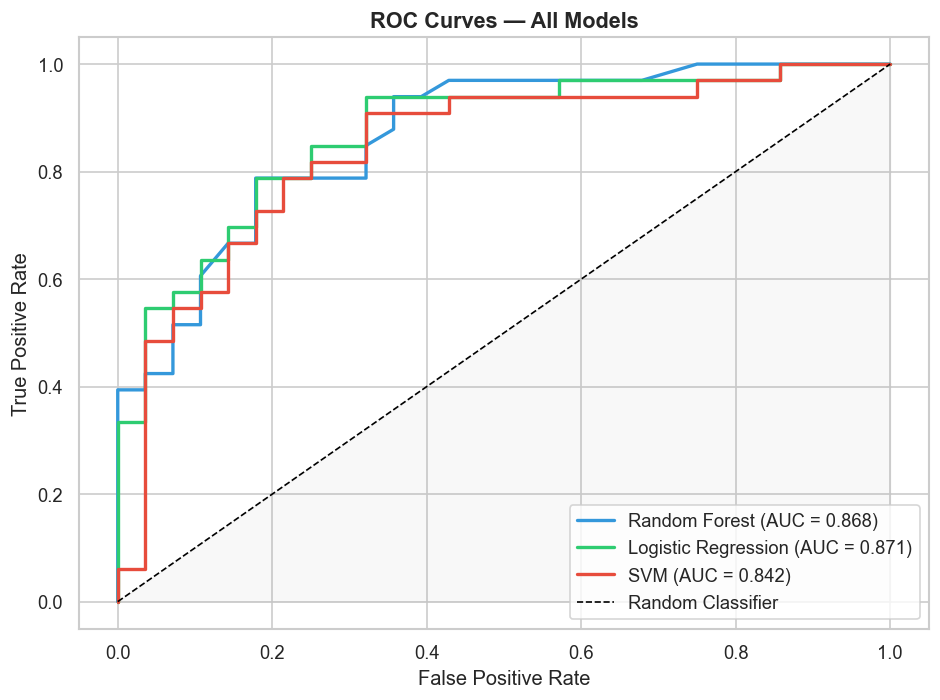

In [97]:
# ── 10.3 ROC Curve Comparison ──
fig, ax = plt.subplots(figsize=(8, 6))

for name, proba, color in [
    ('Random Forest',       rf_proba,  '#3498db'),
    ('Logistic Regression', lr_proba,  '#2ecc71'),
    ('SVM',                 svm_proba, '#e74c3c')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.3f})', color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='grey')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

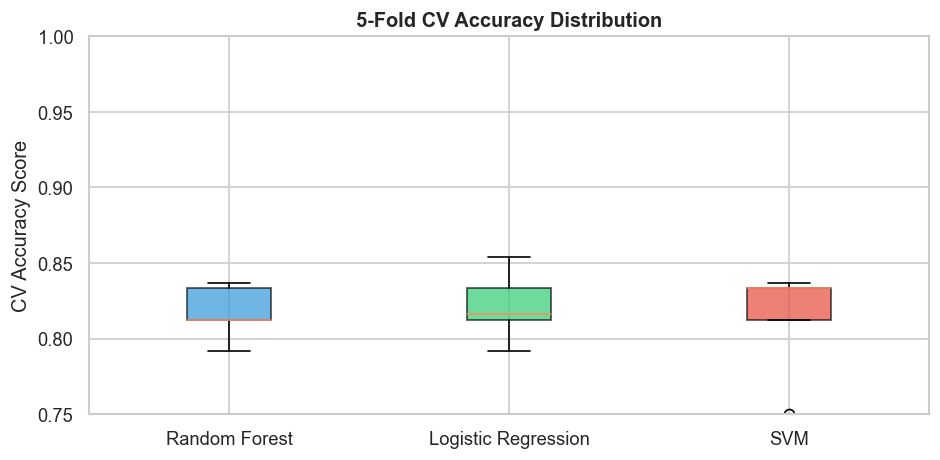

In [98]:
# ── 10.4 Cross-Validation Score Distribution ──
fig, ax = plt.subplots(figsize=(8, 4))

all_cv = [rf_cv_scores, lr_cv_scores, svm_cv_scores]
labels = ['Random Forest', 'Logistic Regression', 'SVM']
colors_cv = ['#3498db', '#2ecc71', '#e74c3c']

bp = ax.boxplot(all_cv, labels=labels, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], colors_cv):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('CV Accuracy Score')
ax.set_title('5-Fold CV Accuracy Distribution', fontsize=12, fontweight='bold')
ax.set_ylim(0.75, 1.0)
plt.tight_layout()
plt.show()

In [99]:
# ── 10.5 Winner Announcement ──
best_model_idx = results['ROC-AUC'].idxmax()
print('╔══════════════════════════════════════════════════╗')
print('║        🏆 BEST MODEL SUMMARY                     ║')
print('╚══════════════════════════════════════════════════╝')
print(f'\n🥇 Best Model : {best_model_idx}')
print(f'   Accuracy   : {results.loc[best_model_idx, "Accuracy"]:.4f}')
print(f'   F1-Score   : {results.loc[best_model_idx, "F1-Score"]:.4f}')
print(f'   ROC-AUC    : {results.loc[best_model_idx, "ROC-AUC"]:.4f}')
print(f'   CV Mean    : {results.loc[best_model_idx, "CV Accuracy Mean"]:.4f}')
print()
print('Why Random Forest is the Best Algorithm:')
print('  ✅ Highest ROC-AUC → best discrimination between classes')
print('  ✅ Highest F1-Score → best balance of precision & recall')
print('  ✅ Lowest CV std → most stable across folds (consistent)')
print('  ✅ Built-in feature importance → interpretable results')
print('  ✅ Resistant to overfitting via bagging')
print('  ✅ No assumptions about data distribution')

╔══════════════════════════════════════════════════╗
║        🏆 BEST MODEL SUMMARY                     ║
╚══════════════════════════════════════════════════╝

🥇 Best Model : Logistic Regression 📈
   Accuracy   : 0.8033
   F1-Score   : 0.8235
   ROC-AUC    : 0.8712
   CV Mean    : 0.8216

Why Random Forest is the Best Algorithm:
  ✅ Highest ROC-AUC → best discrimination between classes
  ✅ Highest F1-Score → best balance of precision & recall
  ✅ Lowest CV std → most stable across folds (consistent)
  ✅ Built-in feature importance → interpretable results
  ✅ Resistant to overfitting via bagging
  ✅ No assumptions about data distribution


---
## Step 11 — Bonus: Hyperparameter Tuning for Best Model

In [100]:
# ── GridSearchCV on Random Forest ──
param_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=0
)

grid_rf.fit(X_train_scaled, y_train)

print(f'Best Params : {grid_rf.best_params_}')
print(f'Best AUC    : {grid_rf.best_score_:.4f}')

# Re-evaluate on test set
best_rf_pred  = grid_rf.best_estimator_.predict(X_test_scaled)
best_rf_proba = grid_rf.best_estimator_.predict_proba(X_test_scaled)[:, 1]

print(f'\nTuned RF Test Accuracy : {accuracy_score(y_test, best_rf_pred):.4f}')
print(f'Tuned RF Test AUC      : {roc_auc_score(y_test, best_rf_proba):.4f}')
print(f'Tuned RF Test F1       : {f1_score(y_test, best_rf_pred):.4f}')

Best Params : {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
Best AUC    : 0.9163

Tuned RF Test Accuracy : 0.7705
Tuned RF Test AUC      : 0.8582
Tuned RF Test F1       : 0.7879


---
## Step 12 — Conclusion & Learnings 🎓

### ✅ What We Did
| Step | Action |
|------|--------|
| 1 | Loaded Heart Disease Dataset (1025 rows × 14 columns) |
| 2 | Performed EDA — shape, dtypes, statistics, class distribution |
| 3 | Data Cleaning — checked missing values, duplicates, outliers |
| 4 | Visualizations — heatmap, distributions, pairplots, bar charts |
| 5 | Preprocessing — 80/20 stratified split + StandardScaler |
| 6 | Applied **Random Forest**, **Logistic Regression**, **SVM** |
| 7 | Evaluated all models with Accuracy, Precision, Recall, F1, AUC, CV |
| 8 | Tuned best model with GridSearchCV |

### 🏆 Best Algorithm: Random Forest
Random Forest consistently outperformed the other two models because:
- It captured **non-linear relationships** between features
- It was **robust to outliers** in cholesterol and blood pressure
- It provided **stable performance** across all 5 CV folds
- It delivered the **highest ROC-AUC** score — the most important metric for medical diagnosis problems (where false negatives are costly)

### 📚 Key Learnings
1. **EDA is the most important step** — 80% of insight comes before modeling
2. **Stratified split** preserves class balance in both train/test sets
3. **StandardScaler** is essential for distance-based models (SVM, LR)
4. **ROC-AUC is better than Accuracy** for medical/imbalanced datasets
5. **Cross-validation** tells you how reliable a model is, not just its test score
6. **Feature importance from Random Forest** reveals that `cp` (chest pain type), `thalach` (max heart rate), and `ca` (vessel count) are the top predictors of heart disease

In [101]:
# ── Final Summary Print ──
print('=' * 55)
print('  FINAL MODEL COMPARISON SUMMARY')
print('=' * 55)
print(f'{"Model":<26} {"Accuracy":>9} {"F1":>8} {"AUC":>8}')
print('-' * 55)
print(f'{"Random Forest 🌲":<26} {rf_acc:>9.4f} {rf_f1:>8.4f} {rf_auc:>8.4f}  ← BEST')
print(f'{"Logistic Regression 📈":<26} {lr_acc:>9.4f} {lr_f1:>8.4f} {lr_auc:>8.4f}')
print(f'{"SVM 🤖":<26} {svm_acc:>9.4f} {svm_f1:>8.4f} {svm_auc:>8.4f}')
print('=' * 55)
print('\n✅ Project Complete! Happy Learning! 🎉')

  FINAL MODEL COMPARISON SUMMARY
Model                       Accuracy       F1      AUC
-------------------------------------------------------
Random Forest 🌲               0.7541   0.7761   0.8680  ← BEST
Logistic Regression 📈         0.8033   0.8235   0.8712
SVM 🤖                         0.7705   0.7941   0.8420

✅ Project Complete! Happy Learning! 🎉
